In [1]:
# information about the dataset

import pandas as pd

df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nAttrition Distribution:")
print(df['Attrition'].value_counts())
print("\nMissing Values:")
print(df.isnull().sum().sum())

Shape: (1470, 35)

Columns: ['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']

Attrition Distribution:
Attrition
No     1233
Yes     237
Name: count, dtype: int64

Missing Values:
0


In [2]:
#Cell 1: Importing necessary libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, roc_auc_score, precision_recall_curve
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
import shap
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

c:\Users\meetc\Desktop\Employee_Attrition_Predictor\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# Cell 2 — Data Loading and Initial Exploration 
df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")

# Drop useless columns
df = df.drop(['EmployeeCount', 'EmployeeNumber', 'Over18', 'StandardHours'], axis=1)

print("Shape after dropping:", df.shape)
print("\nAttrition Distribution:")
print(df['Attrition'].value_counts())

Shape after dropping: (1470, 31)

Attrition Distribution:
Attrition
No     1233
Yes     237
Name: count, dtype: int64


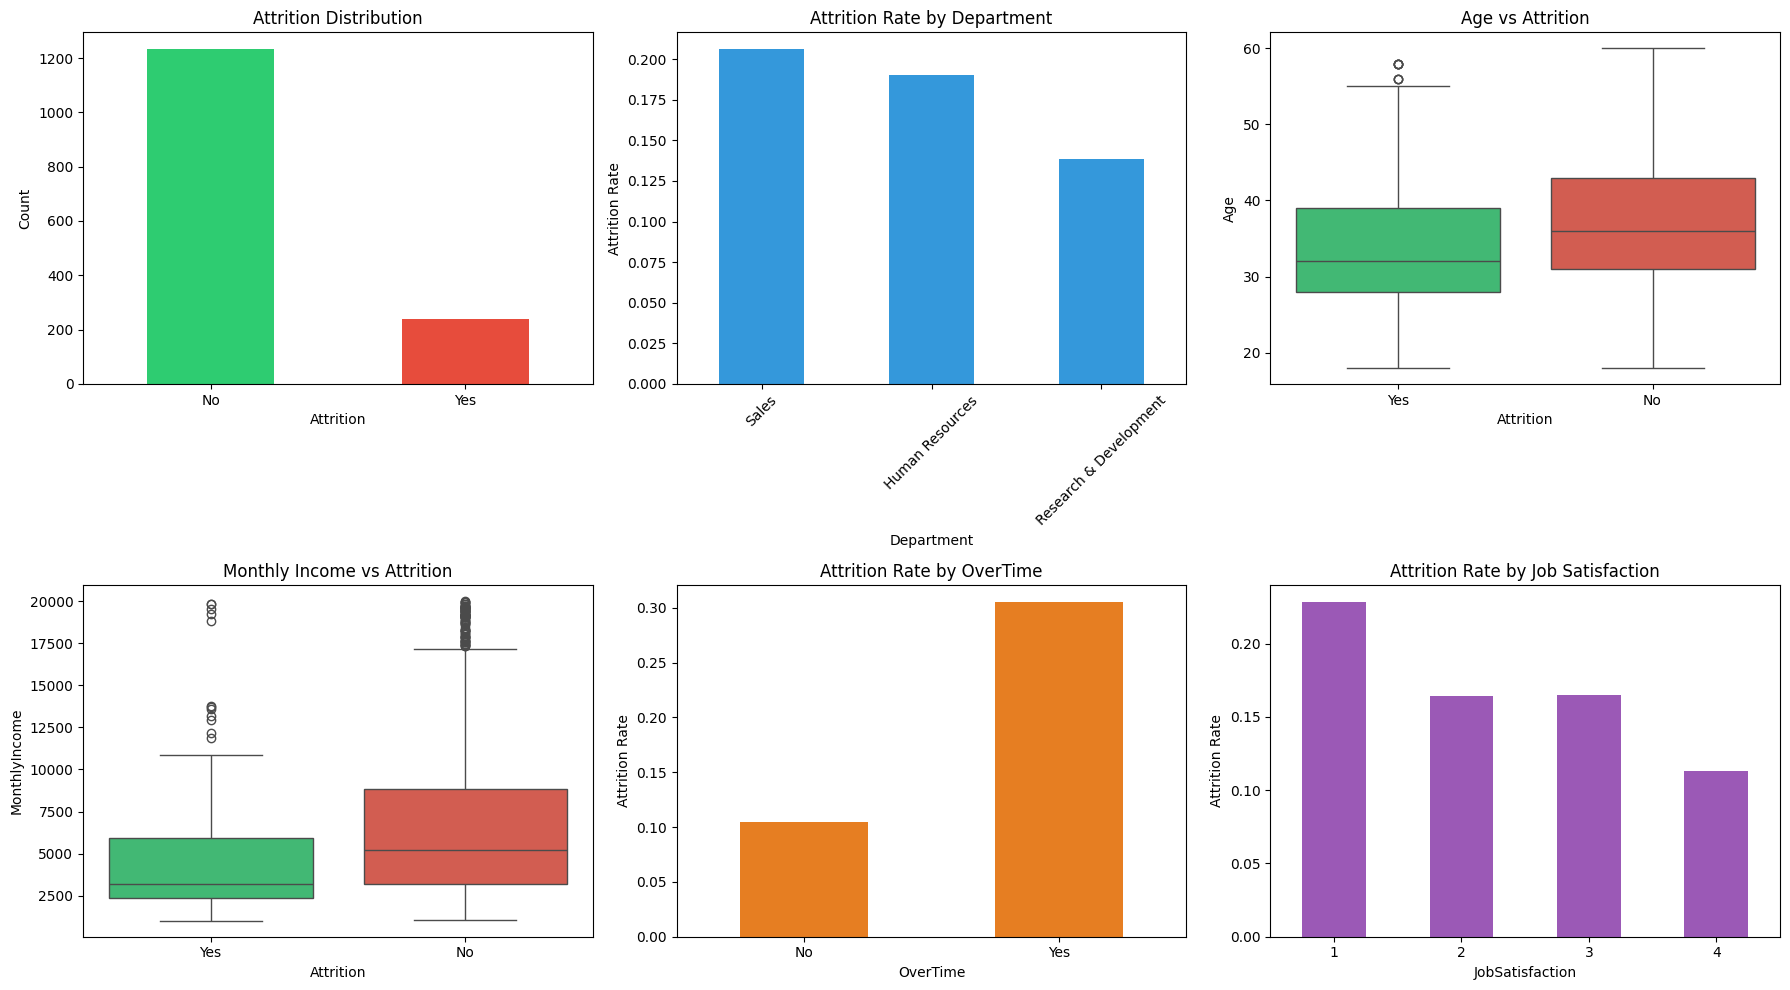

EDA plots saved!


In [4]:
# Cell 3 — Exploratory Data Analysis (EDA) and Visualization

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Plot 1 — Attrition Distribution
df['Attrition'].value_counts().plot(
    kind='bar', ax=axes[0, 0], color=['#2ecc71', '#e74c3c']
)
axes[0, 0].set_title('Attrition Distribution')
axes[0, 0].set_xticklabels(['No', 'Yes'], rotation=0)
axes[0, 0].set_ylabel('Count')

# Plot 2 — Attrition by Department
dept_attr = df.groupby('Department')['Attrition'].apply(
    lambda x: (x == 'Yes').mean()
).sort_values(ascending=False)
dept_attr.plot(kind='bar', ax=axes[0, 1], color='#3498db')
axes[0, 1].set_title('Attrition Rate by Department')
axes[0, 1].set_ylabel('Attrition Rate')
axes[0, 1].tick_params(axis='x', rotation=45)

# Plot 3 — Attrition by Age
sns.boxplot(x='Attrition', y='Age', data=df,
            ax=axes[0, 2], palette=['#2ecc71', '#e74c3c'])
axes[0, 2].set_title('Age vs Attrition')

# Plot 4 — Attrition by Monthly Income
sns.boxplot(x='Attrition', y='MonthlyIncome', data=df,
            ax=axes[1, 0], palette=['#2ecc71', '#e74c3c'])
axes[1, 0].set_title('Monthly Income vs Attrition')

# Plot 5 — Attrition by OverTime
overtime_attr = df.groupby('OverTime')['Attrition'].apply(
    lambda x: (x == 'Yes').mean()
)
overtime_attr.plot(kind='bar', ax=axes[1, 1], color='#e67e22')
axes[1, 1].set_title('Attrition Rate by OverTime')
axes[1, 1].set_ylabel('Attrition Rate')
axes[1, 1].tick_params(axis='x', rotation=0)

# Plot 6 — Attrition by Job Satisfaction
jobsat_attr = df.groupby('JobSatisfaction')['Attrition'].apply(
    lambda x: (x == 'Yes').mean()
)
jobsat_attr.plot(kind='bar', ax=axes[1, 2], color='#9b59b6')
axes[1, 2].set_title('Attrition Rate by Job Satisfaction')
axes[1, 2].set_ylabel('Attrition Rate')
axes[1, 2].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('eda_plots.png', dpi=150)
plt.show()
print("EDA plots saved!")

In [5]:
# Cell 4 — Data Preprocessing and Feature Engineering and Encoding categorical variables

# Reload fresh data
df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")

# Drop useless columns
df = df.drop(['EmployeeCount', 'EmployeeNumber', 'Over18', 'StandardHours'], axis=1)

# Encode target FIRST
df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})

print("Attrition after encoding:")
print(df['Attrition'].value_counts())
print("NaN in Attrition:", df['Attrition'].isnull().sum())

# Now encode remaining categorical columns
cat_cols = df.select_dtypes(include='object').columns.tolist()
print("\nCategorical columns:", cat_cols)

for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])

print("\nShape after encoding:", df.shape)
print("All dtypes numeric:", (df.dtypes == 'object').sum() == 0)

Attrition after encoding:
Attrition
0    1233
1     237
Name: count, dtype: int64
NaN in Attrition: 0

Categorical columns: ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']

Shape after encoding: (1470, 31)
All dtypes numeric: True


In [6]:
#cell 5 — Model Training and Evaluation and Feature Importance

X = df.drop('Attrition', axis=1)
y = df['Attrition']

print("Features shape:", X.shape)
print("Target distribution:")
print(y.value_counts())
print("\nFeature columns:")
print(X.columns.tolist())

Features shape: (1470, 30)
Target distribution:
Attrition
0    1233
1     237
Name: count, dtype: int64

Feature columns:
['Age', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


In [7]:
#cell 6 — Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)
print("\nTrain target distribution:")
print(y_train.value_counts(normalize=True).round(4))

Train size: (1176, 30)
Test size: (294, 30)

Train target distribution:
Attrition
0    0.8384
1    0.1616
Name: proportion, dtype: float64


In [8]:
#cell 7 — Handling Class Imbalance with SMOTE

smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts())
print("\nAfter SMOTE:", pd.Series(y_train_balanced).value_counts())

Before SMOTE: Attrition
0    986
1    190
Name: count, dtype: int64

After SMOTE: Attrition
0    986
1    986
Name: count, dtype: int64


In [9]:
#cell 8 — XGBoost Model Training and Evaluation with Probabilities

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='auc'
)

xgb_model.fit(
    X_train_balanced, y_train_balanced,
    eval_set=[(X_test, y_test)],
    verbose=50
)

y_pred = xgb_model.predict(X_test)
y_proba = xgb_model.predict_proba(X_test)[:, 1]

print("\n=== XGBoost Results ===")
print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))

# Check probabilities for actual attrition cases
attrition_probs = xgb_model.predict_proba(X_test[y_test==1])[:,1]
print("\nAvg probability for actual attrition:", attrition_probs.mean().round(4))

[0]	validation_0-auc:0.65600
[50]	validation_0-auc:0.74709
[100]	validation_0-auc:0.75605
[150]	validation_0-auc:0.76268
[200]	validation_0-auc:0.76579
[250]	validation_0-auc:0.76854
[299]	validation_0-auc:0.77044

=== XGBoost Results ===
              precision    recall  f1-score   support

           0       0.88      0.91      0.90       247
           1       0.42      0.32      0.36        47

    accuracy                           0.82       294
   macro avg       0.65      0.62      0.63       294
weighted avg       0.80      0.82      0.81       294

ROC-AUC: 0.7704367301231804

Avg probability for actual attrition: 0.3905


In [10]:
#cell 9 — Threshold Optimization using Precision-Recall Curve

precision, recall, thresholds = precision_recall_curve(y_test, y_proba)
f1 = 2 * (precision * recall) / (precision + recall + 1e-9)
best_idx = np.argmax(f1)
best_threshold = thresholds[best_idx]

print("Best Threshold:", round(best_threshold, 4))
print("Best F1:", round(f1[best_idx], 4))

Best Threshold: 0.1538
Best F1: 0.5042


In [11]:
# Override threshold to something more practical
best_threshold = 0.30

print("Using threshold:", best_threshold)

Using threshold: 0.3


In [12]:
os.makedirs("models", exist_ok=True)

joblib.dump({
    "model": xgb_model,
    "features": X_train.columns.tolist(),
    "threshold": best_threshold
}, "models/attrition_model.pkl")

print("Model saved!")
print("Threshold:", best_threshold)

Model saved!
Threshold: 0.3


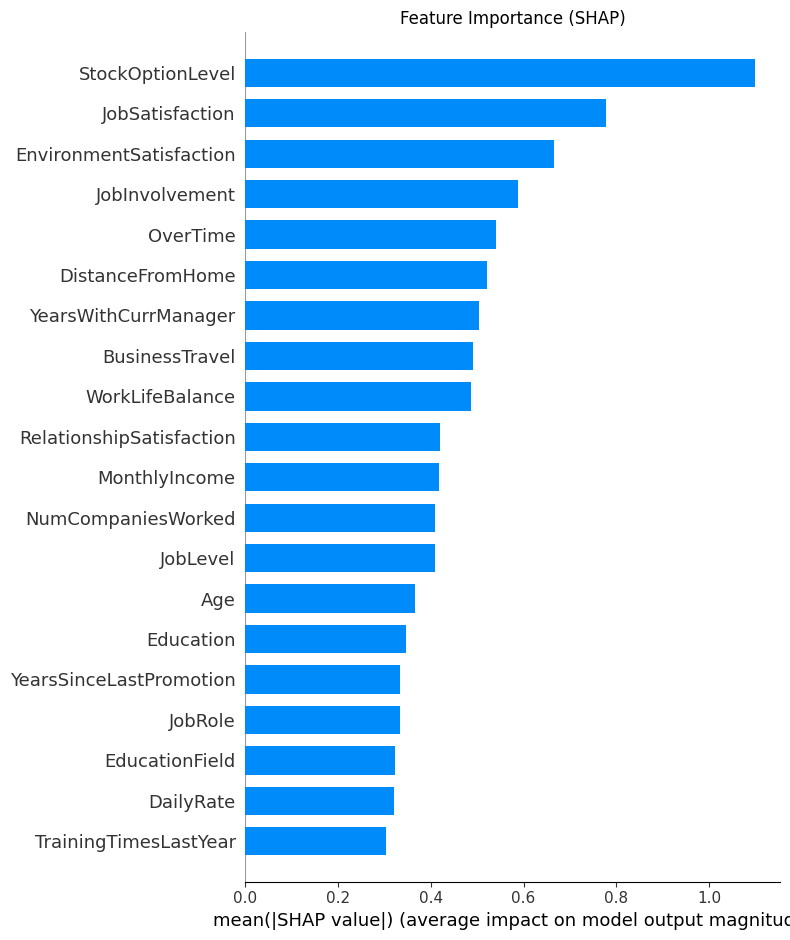

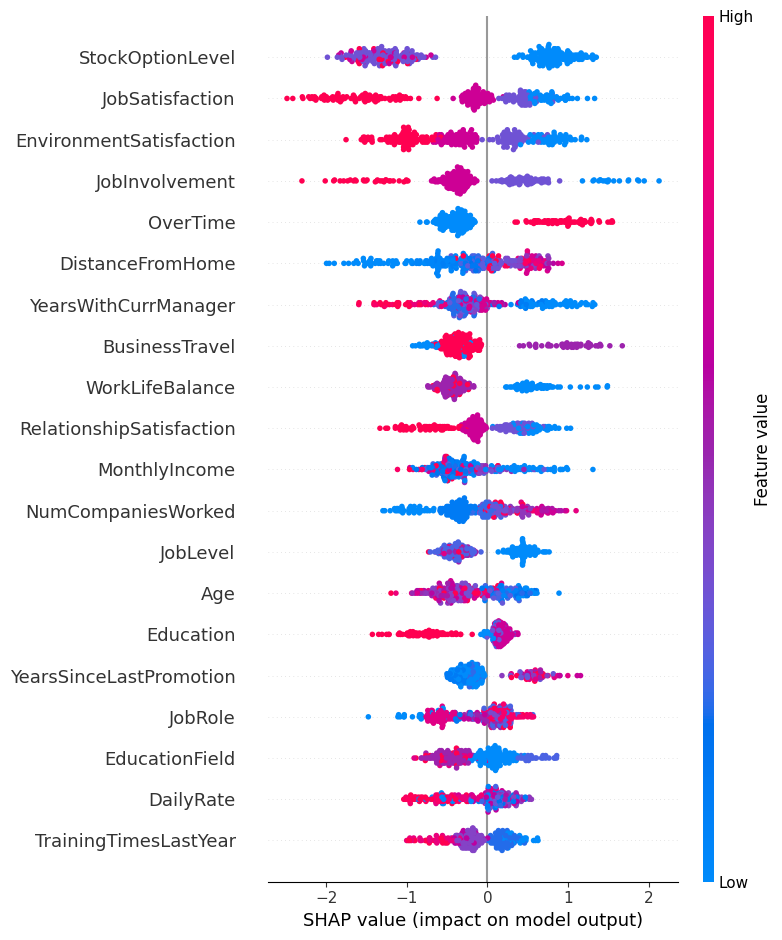

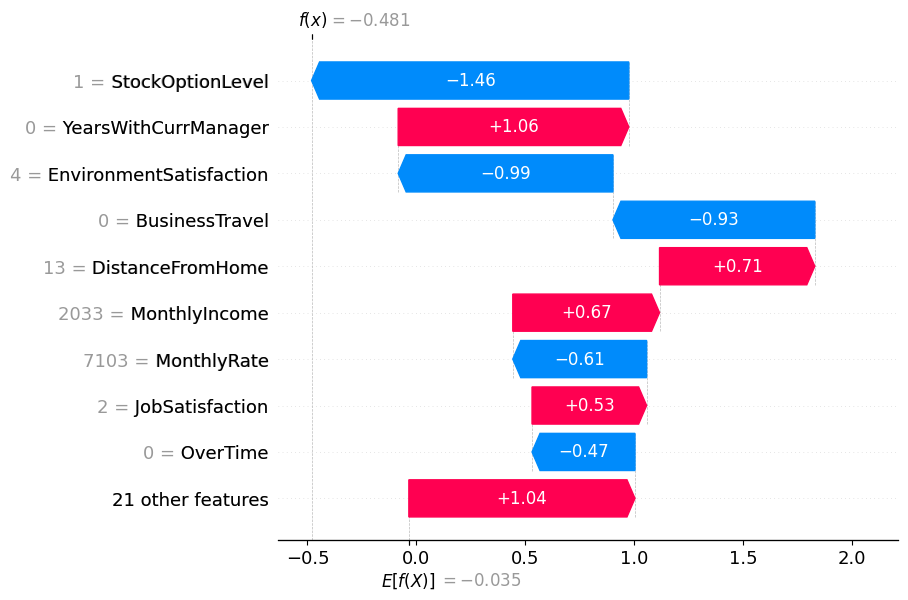

<Figure size 640x480 with 0 Axes>

In [ ]:
import shap

# Create explainer
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)

# 1. Global feature importance - sabse important features
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values[1], X_test, plot_type="bar", show=False)
plt.title("Feature Importance (SHAP) - Attrition Predictions")
plt.tight_layout()
plt.savefig("shap_importance.png", dpi=150, bbox_inches='tight')
plt.show()

# 2. Detailed summary plot - direction bhi dikhata hai
shap.summary_plot(shap_values[1], X_test, show=False)
plt.tight_layout()
plt.savefig("shap_summary.png", dpi=150, bbox_inches='tight')
plt.show()

# 3. Single employee explanation - sabse impressive
shap.waterfall_plot(shap.Explanation(
    values=shap_values[1][0],
    base_values=explainer.expected_value[1],
    data=X_test.iloc[0],
    feature_names=X_test.columns.tolist()
))
plt.savefig("shap_waterfall.png", dpi=150, bbox_inches='tight')
plt.show()